## Evaluation
Evaluar los resultados en cuanto a la detección del punto central de la elipse de cada ratón.

Objetivo:
- Calcular TPR y PPV para imagenes con y sin overlap
- Calcular OKS para el punto de spine_3 o spine_4 en comparación con el punto central de la elipse


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

"df" dataFrame de los blobs detectados para las 161 imágenes con threshold en 49 y max_defect_threshold en 12


In [2]:
#file_name = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\no_labels_test_42.csv'
file_name = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\github\photoneu\raspberryPi\logs'
file_name += r'\2025_06_27_12_59_32_no_labels_test_60.csv'
df = pd.DataFrame() 
df = pd.read_csv(file_name)
# Multiplizar por 2 coordenadas mus y por 4 mus_i_area
df.head()

,Unnamed: 0,img_path,num_mice,num_blobs,num_inter_points,overlaps,mus_1_x,mus_2_x,mus_3_x,mus_1_y,mus_2_y,mus_3_y,mus_1_area,mus_2_area,mus_3_area
0,0,/img00.png,3,2,3,1,102,136,303.0,234,191,56.0,1195,2687,636.0
1,1,/img0000.png,3,5,0,0,140,86,208.0,215,120,68.0,2574,3134,2836.0
2,2,/img0000_1.png,3,5,0,0,217,29,129.0,206,143,88.0,3151,3204,3034.0
3,3,/img0000_2.png,3,5,0,0,309,79,254.0,171,163,119.0,2142,3008,2857.0
4,4,/img0000_20.png,3,5,0,0,28,287,79.0,209,217,60.0,2669,2476,1979.0


Como se ha realizado un resize de las imágenes a la mitad, los valores de coordenadas se multiplican x2 y las áreas x4.

In [3]:
columns_to_multiply = [f"mus_{i}_{j}" for i in range(1, 4) for j in ["x", "y"]]

# Asegurar que los valores son float y multiplicar por 2
for col in columns_to_multiply:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0) * 2

columns_to_multiply = [f"mus_{i}_area" for i in range(1, 4)]

# Asegurar que los valores son float y multiplicar por 2
for col in columns_to_multiply:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0) * 4


In [4]:
df.describe()

,Unnamed: 0,num_mice,num_blobs,num_inter_points,overlaps,mus_1_x,mus_2_x,mus_3_x,mus_1_y,mus_2_y,mus_3_y,mus_1_area,mus_2_area,mus_3_area
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,80.000000,3.049689,3.863354,1.136646,0.813665,221.416149,322.273292,362.509317,368.086957,229.093168,133.105590,9583.677019,10233.490683,8962.136646
std,46.620811,0.350022,0.711485,0.754129,0.390592,181.274466,192.283839,218.628370,93.564242,110.530754,98.840756,2354.435940,2281.589745,4429.375103
min,0.000000,2.000000,2.000000,0.000000,0.000000,4.000000,6.000000,0.000000,134.000000,18.000000,0.000000,660.000000,2108.000000,0.000000
25%,40.000000,3.000000,3.000000,1.000000,1.000000,48.000000,146.000000,122.000000,354.000000,142.000000,66.000000,8872.000000,8744.000000,6196.000000
50%,80.000000,3.000000,4.000000,1.000000,1.000000,188.000000,348.000000,414.000000,376.000000,176.000000,116.000000,9984.000000,10412.000000,10720.000000
75%,120.000000,3.000000,4.000000,2.000000,1.000000,348.000000,502.000000,572.000000,440.000000,326.000000,160.000000,10840.000000,11852.000000,11972.000000
max,160.000000,5.000000,6.000000,3.000000,1.000000,628.000000,808.000000,666.000000,514.000000,480.000000,494.000000,17152.000000,17376.000000,23148.000000


Exploración de los Datos. Número de ratones detectados.

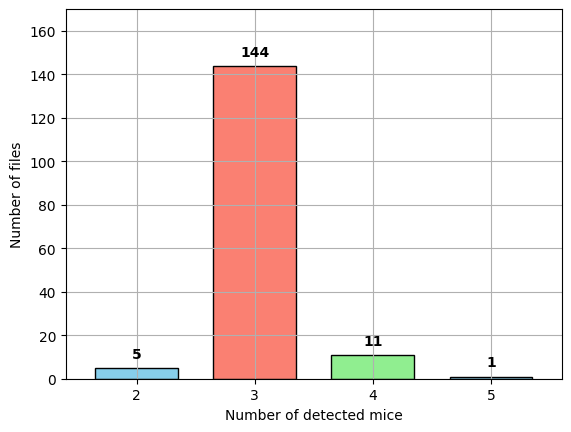

In [22]:
m = df['num_mice'].median()
s = df['num_mice'].std()
#x = np.random.normal(-0.04,0.04,size=len(df['num_mice']))
f = df['num_mice'].value_counts().sort_index()
plt.figure()
ax = f.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'], 
                      edgecolor='black', width=0.7)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=10, fontweight='bold')
plt.ylim(0,170)
plt.xlabel('Number of detected mice')
plt.ylabel('Number of files')
plt.xticks(rotation=0)
#plt.title('Number of mice detected per image')

plt.grid(True)
plt.show()


Constante k, para el OKS, a partir del área de la elipse del ratón nº1

"df_test" DataFrame con los datos de las etiquetas de las imagenes de Tri-mice

In [24]:
test_file = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\deeplabcut\labeled-data-ordered\CollectedData_dlc.csv'
df_test = pd.DataFrame()
df_test = pd.read_csv(test_file)
df_test.head(20)

,scorer,dlc,dlc.1,dlc.2,dlc.3,dlc.4,dlc.5,dlc.6,dlc.7,dlc.8,...,dlc.62,dlc.63,dlc.64,dlc.65,dlc.66,dlc.67,dlc.68,dlc.69,dlc.70,dlc.71
0,individuals,mus1,mus1,mus1,mus1,mus1,mus1,mus1,mus1,mus1,...,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3
1,bodyparts,snout,snout,leftear,leftear,rightear,rightear,shoulder,shoulder,spine1,...,spine4,spine4,tailbase,tailbase,tail1,tail1,tail2,tail2,tailend,tailend
2,coords,x,y,x,y,x,y,x,y,x,...,x,y,x,y,x,y,x,y,x,y
3,/img0038.png,577.0738982187231,251.0082247294906,575.3425399593766,273.5158821009952,596.5516786363714,272.65020297132196,586.1635290802924,281.7398338328911,586.1635290802924,...,NaN,NaN,NaN,NaN,NaN,NaN,127.01268085145685,332.08101456949316,162.72616092026604,331.8041658867892
4,/img0303.png,608.6823002384388,64.52077380905499,599.5926693768697,72.7840745922997,613.6402807083857,86.00535584549127,599.1795043377074,84.35269568884232,592.5688637111116,...,98.23955027247223,106.37117408591845,114.9010628721575,116.01731295942045,139.16256367520796,127.41729526446827,164.88560067121327,155.47879016920132,177.74711916921592,185.29412850548022
5,/img0502.png,391.6471699771854,235.93936498314736,411.53389946420856,212.30042238536515,384.51796506674316,206.67210271922653,401.0277027540831,199.5428978087843,404.7799158648422,...,101.12823717208212,99.68967706042972,116.58679305910454,109.58315282812407,141.9388247138213,125.6600509506274,166.05417189757628,147.9203714279397,188.62366349262902,178.21914096650363
6,/img0707.png,257.3440332490244,293.13160905008624,263.3644381053884,325.8138068417765,284.579198075433,312.33956740134283,279.70553700123355,326.9605506239411,288.592801313009,...,165.9229305514636,227.64039709550153,161.69290753146925,214.95032803551857,149.0028384714863,187.4551784055555,148.15683386748742,146.4239551116106,157.03988220947554,118.50580317964813
7,/img1138.png,280.5087701635501,316.5274748962508,286.18023465904184,290.0606405839558,260.1860223880378,299.9857034510664,270.58370729643946,283.44393200588206,265.85748688352965,...,574.6312641868317,137.98898003862422,566.3454782313877,156.0670584868657,549.0206530518229,185.44393596525813,531.3192012379199,209.17141392857508,507.2150966402645,233.2755185262304
8,/img1331.png,608.5274787976398,367.97728503505004,601.0230525761217,362.4740391392701,600.5227574946871,386.4882030481282,591.0171509474308,369.47817027935366,575.0077083415254,...,544.6293163108479,113.1035109963922,556.4080534247164,103.24224271501399,589.2789476959771,93.10705031470859,616.3974354697672,100.22907740681508,634.2025032000334,113.92528335317371
9,/img1501.png,442.834413410453,200.11096701580038,472.12863344437835,207.3620115786532,466.9078813591243,182.70846006495367,482.5701376148864,189.95950462780647,494.7518924804791,...,475.5193165256127,124.02018734728036,490.2791046451348,129.8554524177891,527.6934512736909,138.09347369380146,560.9887872642407,141.52598255880662,594.9706250277918,143.5854878778097


In [208]:
df_test.describe()

,scorer,dlc,dlc.1,dlc.2,dlc.3,dlc.4,dlc.5,dlc.6,dlc.7,dlc.8,...,dlc.62,dlc.63,dlc.64,dlc.65,dlc.66,dlc.67,dlc.68,dlc.69,dlc.70,dlc.71
count,115,113,113,114,114,114,114,115,115,115,...,113,113,113,113,114,114,112,112,113,113
unique,115,112,112,105,106,111,111,108,106,109,...,99,102,106,107,107,105,101,104,102,103
top,individuals,25.472,166.13004622267232,431.08,148.237,26.606,171.497,41.962,145.642,423.544,...,76.852,384.811,86.333,393.538,106.745,412.526,147.788,413.388,164.943,89.953
freq,1,2,2,3,3,3,2,2,3,3,...,3,3,3,3,3,4,4,4,3,3


Adaptación de los datos del dataset hacia el formato de no_label_test


In [25]:
def compute_euclidean_distances(df):
    # Elimina filas con NaNs en cualquiera de las 4 columnas relevantes
    clean_df = df.dropna(subset=['xs1', 'ys1', 'xs2', 'ys2'])

    # Calcula distancia euclidiana por fila
    distances = np.sqrt(
        (clean_df['xs1'] - clean_df['xs2'])**2 +
        (clean_df['ys2'] - clean_df['ys2'])**2
    )

    return distances

In [45]:
# Cálculo de la constate k para el OKS
xs1 = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == 'spine1') & (df_test.iloc[2] == 'x')].dropna()
xs2 = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == 'spine2') & (df_test.iloc[2] == 'x')].dropna()
ys1 = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == 'spine1') & (df_test.iloc[2] == 'y')].dropna()
ys2 = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == 'spine2') & (df_test.iloc[2] == 'y')].dropna()

df_k = pd.DataFrame()
df_k['xs1'] = xs1.loc[3:,:].astype(float) #xs1.values[0][3:]
df_k['xs2'] = xs2.loc[3:,:].astype(float) #xs1.values[0][3:]
df_k['ys1'] = ys1.loc[3:,:].astype(float) #xs1.values[0][3:]
df_k['ys2'] = ys2.loc[3:,:].astype(float) #xs1.values[0][3:]
d = np.sqrt((df_k['xs1'] - df_k['xs2'])**2 + (df_k['ys1'] - df_k['ys2'])**2)
#d.mean()/np.sqrt(1500)
df['mus_1_area'] = df['mus_1_area'].astype(float)
k = d.mean()/np.sqrt(df['mus_1_area'].mean())
k

0.17116046475620927

"df_clean", reajusta el formato de df_test para tomar las coordenadas de spine2

In [39]:
field = 'spine2'
df_clean = pd.DataFrame()
df_clean["img_path"] = df_test["scorer"]
df_clean.drop([0,1,2], inplace=True)
col = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'x')]
df_clean["mus_1_x"] = col
col = df_test.loc[:, (df_test.iloc[0] == 'mus1') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'y')]
df_clean["mus_1_y"] = col
col = df_test.loc[:, (df_test.iloc[0] == 'mus2') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'x')]
df_clean["mus_2_x"] = col
col = df_test.loc[:, (df_test.iloc[0] == 'mus2') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'y')]
df_clean["mus_2_y"] = col
col = df_test.loc[:, (df_test.iloc[0] == 'mus3') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'x')]
df_clean["mus_3_x"] = col
col = df_test.loc[:, (df_test.iloc[0] == 'mus3') & (df_test.iloc[1] == field) & (df_test.iloc[2] == 'y')]
df_clean["mus_3_y"] = col
df_clean.head(30)


,img_path,mus_1_x,mus_1_y,mus_2_x,mus_2_y,mus_3_x,mus_3_y
3,/img0038.png,585.2978499506191,313.337122065965,96.94862418821859,320.6372283383545,45.34231945379248,398.52469841844044
4,/img0303.png,584.7187279670292,109.96892811690094,118.75671058567993,338.86136203326316,69.30113365196624,85.0327456687777
5,/img0502.png,410.0330142199049,165.77297981195258,527.4234560583649,422.39847716466613,69.59278316255637,81.44858111374327
6,/img0707.png,296.9066937337021,355.91583112359655,515.3951513434035,163.80427650680974,179.03600191344594,257.6735605374612
7,/img1138.png,258.2955342228739,251.30563319809525,338.64128124234094,220.5852005141814,586.6833164856594,107.48222265721671
8,/img1331.png,556.9970854098818,373.48053093083,492.9593149862602,337.45928506754285,525.1807038670187,132.82604755914863
9,/img1501.png,511.57431586629764,184.44871076003832,467.61059178775145,321.89416673586015,440.16447521605966,107.88739568175617
10,/img1587.png,592.8533382415478,256.663386069942,333.5988057383355,283.08709640290306,505.6749986601078,108.45313141934668
11,/img1677.png,517.7079152366416,269.58933863952836,418.5924334784283,339.1280923884774,602.9904619298707,221.3422441495456
12,/img0000_1.png,74.67337285390434,293.42866628130423,258.6109509352304,207.2333580760636,437.72697286947255,399.3713930740071


In [ ]:

#df_clean = df_clean.set_index('img_path').reindex(df['img_path']).reset_index()
#df_clean.head()


In [123]:
df_clean.describe()

,img_path,mus_1_x,mus_1_y,mus_2_x,mus_2_y,mus_3_x,mus_3_y
count,112,112,112,112,112,112,111
unique,112,102,102,103,106,102,100
top,/img0038.png,397.95,169.363,503.006,152.535,63.398,175.186
freq,1,4,4,3,4,3,3


Realizamos la resta de valores en las imágenes coincidentes

In [ ]:
from itertools import product

# Paso 1: Mantener solo filas con img_path común
merged = df_clean.merge(df, on='img_path', suffixes=('_clean', '_df'), how='inner')

# Paso 2: Identificar columnas que terminan en _x o _y
def filter_mus_columns(df):
    return [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]

cols_df = filter_mus_columns(df)
cols_clean = filter_mus_columns(df_clean)

# Paso 3: Asegurar que todos los valores sean float y sin NaN
for col in cols_df:
    merged[col + '_df'] = pd.to_numeric(merged[col + '_df'], errors='coerce').fillna(0.0).astype(float)

for col in cols_clean:
    merged[col + '_clean'] = pd.to_numeric(merged[col + '_clean'], errors='coerce').fillna(0.0).astype(float)

# Paso 4: Generar todas las combinaciones posibles entre columnas con mismo sufijo
result_data = {'img_path': merged['img_path']}
suffixes = ['_x', '_y']

for suffix in suffixes:
    df_cols = [c for c in cols_df if c.endswith(suffix)]
    clean_cols = [c for c in cols_clean if c.endswith(suffix)]
    
    for col_df, col_clean in product(df_cols, clean_cols):
        col_name = f"{col_df}_minus_{col_clean}"
        result_data[col_name] = abs(merged[col_df + '_df'] - merged[col_clean + '_clean'])

# Paso 5: Crear DataFrame final
df_result = pd.DataFrame(result_data)

# Resultado
print(df_result.head())


       img_path  mus_1_x_minus_mus_1_x  mus_1_x_minus_mus_2_x  \
0  /img0038.png             563.297850              74.948624   
1  /img0303.png             476.718728              10.756711   
2  /img0502.png             121.966986               4.576544   
3  /img0707.png              12.906694             231.395151   
4  /img1138.png              71.704466               8.641281   

   mus_1_x_minus_mus_3_x  mus_2_x_minus_mus_1_x  mus_2_x_minus_mus_2_x  \
0              23.342319             507.297850              18.948624   
1              38.698866               7.281272             473.243289   
2             462.407217               2.033014             119.423456   
3             104.963998             120.906694             339.395151   
4             256.683316               8.295534              88.641281   

   mus_2_x_minus_mus_3_x  mus_3_x_minus_mus_1_x  mus_3_x_minus_mus_2_x  \
0              32.657681               8.702150             497.051376   
1             52

In [213]:
df_result.describe()

,mus_1_x_minus_mus_1_x,mus_1_x_minus_mus_2_x,mus_1_x_minus_mus_3_x,mus_2_x_minus_mus_1_x,mus_2_x_minus_mus_2_x,mus_2_x_minus_mus_3_x,mus_3_x_minus_mus_1_x,mus_3_x_minus_mus_2_x,mus_3_x_minus_mus_3_x,mus_1_y_minus_mus_1_y,mus_1_y_minus_mus_2_y,mus_1_y_minus_mus_3_y,mus_2_y_minus_mus_1_y,mus_2_y_minus_mus_2_y,mus_2_y_minus_mus_3_y,mus_3_y_minus_mus_1_y,mus_3_y_minus_mus_2_y,mus_3_y_minus_mus_3_y
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,177.982021,238.432998,137.212175,109.985975,100.856639,237.835213,169.345904,135.895047,209.701851,141.602933,98.354726,102.916707,53.647066,86.883114,107.898510,105.503125,139.720288,147.857941
std,164.255263,209.654939,162.390228,137.801466,144.727974,189.299559,193.533129,154.210758,178.944052,100.329057,83.950307,118.668597,70.623152,90.637686,84.487926,96.536164,115.963266,97.591314
min,1.121431,0.833729,0.308627,0.568864,0.031000,0.552927,0.099000,1.054409,0.819731,0.221790,0.289814,0.379343,0.049000,0.279943,1.731987,0.077000,2.452081,7.801353
25%,18.628820,18.075250,14.984000,13.345539,2.855647,37.650734,8.432237,14.781750,17.516571,43.051000,18.318907,12.746000,15.418420,26.824602,41.334067,39.181500,65.222059,52.274193
50%,104.982602,193.415841,41.935130,81.098000,47.030560,248.950801,81.559035,84.763256,215.894252,168.284416,78.417090,32.920356,24.572714,39.325951,79.878323,67.307133,91.110500,131.513580
75%,361.857500,451.916750,267.894067,133.959500,93.404438,437.675000,281.060500,241.063231,353.880000,207.474000,155.341750,188.307084,47.100017,126.765820,176.230500,135.107782,211.233567,231.434503
max,564.163529,570.760880,552.282678,620.481009,556.553476,736.360997,585.718594,607.981100,562.288125,440.640968,338.258649,369.438118,288.640968,346.333352,359.178038,382.771540,430.336783,434.129976


Cálculo de las distancias entre el centro de la elipse en df_nums, y el keypoint de la spine.

No hay una correspondencia entre los IDs (1,2,3) de los ratones, entre el dataset df_clean (ground-truth) y el de la percepción, df (no_labels), que además será distinto en cada imagen...

Así que se calcula la diferencia y nos quedamos con el mínimo

In [41]:
min_values = []
for index, row in df_result.iterrows():
    row_min = []
    for i in range(1,len(row), 3):
        row_min.append(row[i:i+3].min())
    min_values.append(row_min)
#err_df = pd.DataFrame(min_values, columns=['err_x_1', 'err_x_2', 'err_x_3','err_y_1', 'err_y_2', 'err_y_3','err2_x_1', 'err2_x_2', 'err2_x_3','err2_y_1', 'err2_y_2', 'err2_y_3'])
err_df = pd.DataFrame(min_values, columns=['err_x_1', 'err_x_2', 'err_x_3','err_y_1', 'err_y_2', 'err_y_3'])
err_df.head()


,err_x_1,err_x_2,err_x_3,err_y_1,err_y_2,err_y_3
0,23.342319,18.948624,8.702150,15.475302,2.662878,11.337122
1,10.756711,7.281272,21.301134,6.861362,2.967254,47.032746
2,4.576544,2.033014,19.592783,17.601523,21.772980,55.448581
3,12.906694,3.036002,6.604849,0.084169,9.673561,55.804277
4,8.641281,8.295534,21.316684,22.585201,15.305633,45.482223


In [187]:
err_df.describe()

,err_x_1,err_x_2,err_x_3,err_y_1,err_y_2,err_y_3
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,12.487424,11.165281,17.820567,14.111954,17.303628,42.652318
std,8.688974,20.711351,56.657334,11.112698,12.589378,31.245612
min,0.308627,0.031000,0.099000,0.221790,0.049000,0.077000
25%,6.846819,2.357500,4.722255,7.062146,7.951634,26.164840
50%,14.166448,8.885172,8.883726,14.334714,15.523766,40.013904
75%,16.529500,13.774056,14.110500,18.198722,21.828646,49.743625
max,71.054409,208.624935,486.455479,73.663217,56.961240,227.998449


Calculo de OKS = exp (-di^2/(2s^2 ki^2))
Con di^2 = err2_x + err2_y

In [42]:
#k = 0.107  # según COCO para las caderas de un ser humano
k = 0.3
#k = 1
# k = 2* dev 
#k= 1.25 # porque hay 8 puntos etiquetados entre el hocico y el comienzo de la cola 
#k = 0.23
#err_df['d2_1'] = err_df['err2_x_1'] + err_df['err2_y_1']
#err_df['d2_2'] = err_df['err2_x_2'] + err_df['err2_y_2']
#err_df['d2_3'] = err_df['err2_x_3'] + err_df['err2_y_3']
err_df['d2_1'] = err_df['err_x_1']**2 + err_df['err_y_1']**2
err_df['d2_2'] = err_df['err_x_2']**2 + err_df['err_y_2']**2
err_df['d2_3'] = err_df['err_x_3']**2 + err_df['err_y_3']**2
err_df['s2_1'] = df['mus_1_area'] #**2
err_df['s2_2'] = df['mus_2_area'] #**2
err_df['s2_3'] = df['mus_3_area'] #**2

oks_1 = err_df['d2_1']/(2*err_df['s2_1']*k**2)
err_df['oks_1'] = np.exp(-oks_1)
oks_2 = err_df['d2_2']/(2*err_df['s2_2']*k**2)
err_df['oks_2'] = np.exp(-oks_2)
oks_3 = err_df['d2_3']/(2*err_df['s2_3']*k**2)
err_df['oks_3'] = np.exp(-oks_3)
err_df.describe()

,err_x_1,err_x_2,err_x_3,err_y_1,err_y_2,err_y_3,d2_1,d2_2,d2_3,s2_1,s2_2,s2_3,oks_1,oks_2,oks_3
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,1.120000e+02,1.120000e+02,112.000000
mean,15.088373,12.064556,21.665525,14.506578,16.907160,45.349354,838.365511,1020.139046,6620.451273,9382.642857,10351.178571,8458.071429,7.184340e-01,7.412680e-01,0.318304
std,10.542638,21.353957,56.157204,17.109192,11.749293,31.268966,2545.887026,4470.304008,29093.563348,2766.022027,2507.344463,4515.580139,2.329178e-01,2.135927e-01,0.309724
min,0.119000,0.224187,0.325001,0.009000,0.580537,0.927000,6.129973,2.752209,12.644818,660.000000,2108.000000,0.000000,7.606599e-08,5.374050e-11,0.000000
25%,9.050864,1.745000,6.658387,4.306471,9.248613,25.681215,235.627409,221.953243,964.292798,8423.000000,9648.000000,4328.000000,6.211888e-01,5.998458e-01,0.023765
50%,15.695239,8.290342,13.612500,12.314038,16.068000,41.425205,410.795363,370.262032,2028.303137,9564.000000,10578.000000,10230.000000,7.786567e-01,8.140885e-01,0.259710
75%,19.600750,16.110813,20.774765,18.790283,21.531091,58.055766,792.079505,671.455829,3963.567419,11350.000000,11853.000000,11551.000000,8.799307e-01,8.806147e-01,0.471004
max,91.237353,210.086471,492.959315,152.332773,58.443436,212.574068,23580.393018,47399.646441,260651.645142,17152.000000,17376.000000,23148.000000,9.962550e-01,9.985021e-01,0.992709


In [37]:
# imputar valores nan en oks con la media de la columna
err_df['oks_1'] = err_df['oks_1'].fillna(err_df['oks_1'].mean())
err_df['oks_2'] = err_df['oks_2'].fillna(err_df['oks_2'].mean())
err_df['oks_3'] = err_df['oks_3'].fillna(err_df['oks_3'].mean())

#imprimir cuántos valores no válidos hay en las columnas oks_1, oks_2 y oks_3
print("null oks_1: ", err_df['oks_1'].isnull().sum())
print("null oks_2: ", err_df['oks_2'].isnull().sum())
print("null oks_3: ", err_df['oks_3'].isnull().sum())


null oks_1:  0
null oks_2:  0
null oks_3:  0


### Métricas según si hay o no solapamiento en la imagen
Para spine_2 (k = 1)
OKS 1 = 0.85
OKS 2 = 0.89
OKS 3 = 0.52

Para spine_1 (k = 0.34 )
OKS 1 = 0.48
OKS 2 = 0.54
OKS 3 = 0.16


In [43]:
#tomar los OKS de las filas que tienen overlaps a 1
oks_1 = err_df['oks_1'][df['overlaps'] > 0].mean()
oks_2 = err_df['oks_2'][df['overlaps'] > 0].mean()
oks_3 = err_df['oks_3'][df['overlaps'] > 0].mean()
print(f'OKS 1: {oks_1:.2f}')
print(f'OKS 2: {oks_2:.2f}')
print(f'OKS 3: {oks_3:.2f}')

OKS 1: 0.69
OKS 2: 0.73
OKS 3: 0.29


In [44]:
# tomar los OKS de las filas que tienen overlaps a 0
oks_1 = err_df['oks_1'][df['overlaps'] == 0].dropna().mean()
oks_2 = err_df['oks_2'][df['overlaps'] == 0].mean()
oks_3 = err_df['oks_3'][df['overlaps'] == 0].mean()
print(f'OKS 1: {oks_1:.2f}')
print(f'OKS 2: {oks_2:.2f}')
print(f'OKS 3: {oks_3:.2f}')

OKS 1: 0.79
OKS 2: 0.76
OKS 3: 0.41


###Representación gráfica de los errores en la localización

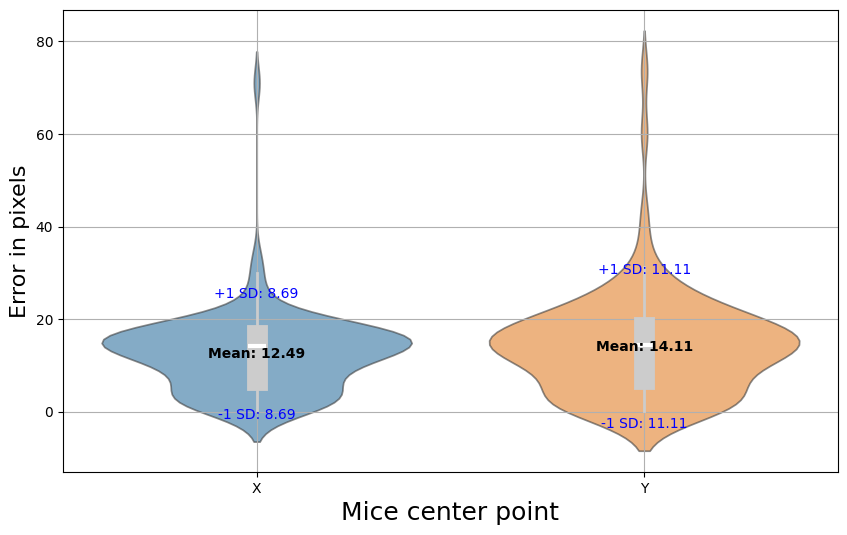

In [230]:
df_min = pd.DataFrame()
df_min.loc[:, 'err_x_1'] = err_df.loc[:, 'err_x_1']
df_min.loc[:, 'err_y_1'] = err_df.loc[:, 'err_y_1']
df_min.head()
# Configurar el gráfico de violín
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_min, alpha=0.6, inner_kws=dict(box_width=15, whis_width=2, color=".8"))  # Crear el diagrama de violín sin la línea interior

# Calcular y etiquetar el valor medio y la desviación estándar para cada columna
for i, col in enumerate(df_min.columns):
    mean = df_min[col].mean()
    std = df_min[col].std()
    
    # Agregar la etiqueta del valor medio
    plt.text(i, mean, f'Mean: {mean:.2f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    # Agregar la etiqueta de la desviación estándar
    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)

# Configurar etiquetas y título
#plt.title('Error de detección entre el centro de la elipse (test) y el punto spine2 (train)')
#plt.xlabel('Posición de los puntos x, y por ratones')
#plt.ylabel('Error en píxeles')
#plt.title('Error between ellipse center (test) and spine2 point (train)')
plt.xticks(np.arange(2),['X','Y'])
plt.xlabel('Mice center point', fontsize=18)
plt.ylabel('Error in pixels',fontsize=16)
#plt.ylim(-15,75)
plt.grid(True)

# Mostrar el gráfico
plt.show()
#frame.shape: 240 x 320

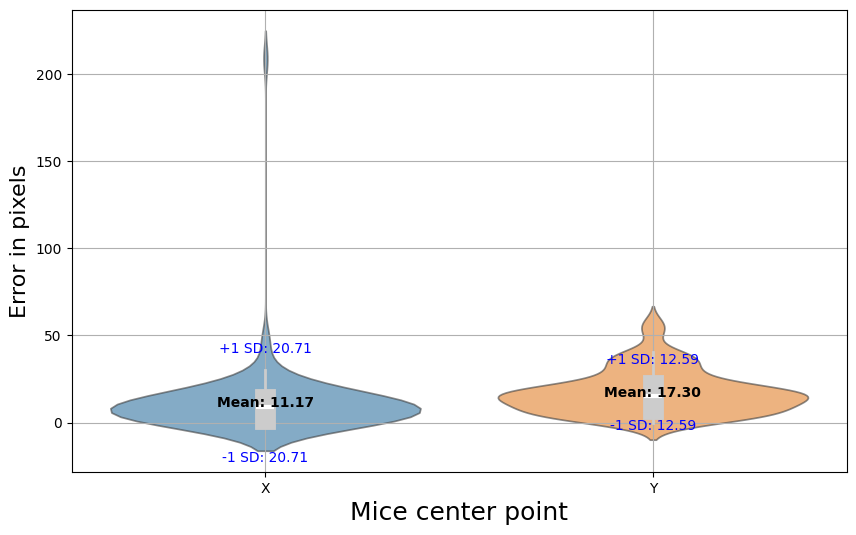

In [231]:
df_min = pd.DataFrame()
df_min.loc[:, 'err_x_2'] = err_df.loc[:, 'err_x_2']
df_min.loc[:, 'err_y_2'] = err_df.loc[:, 'err_y_2']
df_min.head()
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_min, alpha=0.6, inner_kws=dict(box_width=15, whis_width=2, color=".8"))  # Crear el diagrama de violín sin la línea interior
for i, col in enumerate(df_min.columns):
    mean = df_min[col].mean()
    std = df_min[col].std()
    
    # Agregar la etiqueta del valor medio
    plt.text(i, mean, f'Mean: {mean:.2f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    # Agregar la etiqueta de la desviación estándar
    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)

plt.xticks(np.arange(2),['X','Y'])
plt.xlabel('Mice center point', fontsize=18)
plt.ylabel('Error in pixels',fontsize=16)
plt.grid(True)
plt.show()


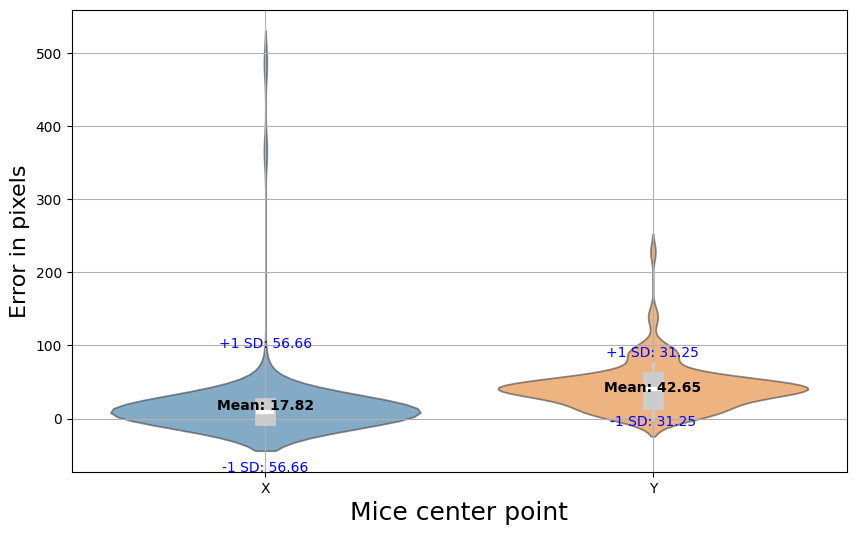

In [232]:
df_min = pd.DataFrame()
df_min.loc[:, 'err_x_3'] = err_df.loc[:, 'err_x_3']
df_min.loc[:, 'err_y_3'] = err_df.loc[:, 'err_y_3']
df_min.head()
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_min, alpha=0.6, inner_kws=dict(box_width=15, whis_width=2, color=".8"))  # Crear el diagrama de violín sin la línea interior
for i, col in enumerate(df_min.columns):
    mean = df_min[col].mean()
    std = df_min[col].std()
    
    # Agregar la etiqueta del valor medio
    plt.text(i, mean, f'Mean: {mean:.2f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    # Agregar la etiqueta de la desviación estándar
    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
plt.xticks(np.arange(2),['X','Y'])
plt.xlabel('Mice center point', fontsize=18)
plt.ylabel('Error in pixels',fontsize=16)
plt.grid(True)
plt.show()

    Cálculo de otras métricas de performance:
- True Positive Rate, TPR:
TPR = TP / (TP + FN)
- Positive Predicted Value:
PPV = TP / (TP + FP)

    En donde:
- TP: numero de ratones correctamente detectados. Es el número total de ratones detectados: 339
- FN: False Negative. Ratones que no se detectaron correctamente.
- TP + FN: número total de ratones: 3x112 = 336 

In [47]:
TP = 442
N_MICES = 3*161
TPR = TP/ N_MICES
print(f'True Positive Rate: {TPR:.3f}')

True Positive Rate: 0.915


In [48]:
TP = 442
FP = 13
PPV = TP/ (TP + FP)
print(f'Positive Predicted Value: {PPV:.3f}')

Positive Predicted Value: 0.971


In [223]:
err_df.head()

,err_x_1,err_x_2,err_x_3,err_y_1,err_y_2,err_y_3,d2_1,d2_2,d2_3,s2_1,s2_2,s2_3,oks_1,oks_2,oks_3
0,18.635892,8.998935,7.836471,2.186565,18.677942,4.677942,352.077531,429.846351,83.293416,4780.0,10748,2544.0,0.740345,0.849390,0.874907
1,12.492285,0.568864,6.101157,8.411691,9.160812,40.309679,226.813728,84.244081,1662.094355,10296.0,12536,11344.0,0.914008,0.972943,0.549894
2,11.960011,3.220084,5.061741,15.947867,38.282717,49.883501,397.376334,1475.935401,2513.984890,12604.0,12816,12136.0,0.879251,0.624968,0.429336
3,4.592801,16.995078,12.644928,13.558408,26.593653,41.566947,204.924260,996.055032,1887.705249,8568.0,12032,11428.0,0.906992,0.713271,0.509557
4,4.119514,15.857487,16.797164,15.023248,22.976752,33.806797,242.668371,779.391029,1425.044238,10676.0,9904,7916.0,0.911397,0.725276,0.479612


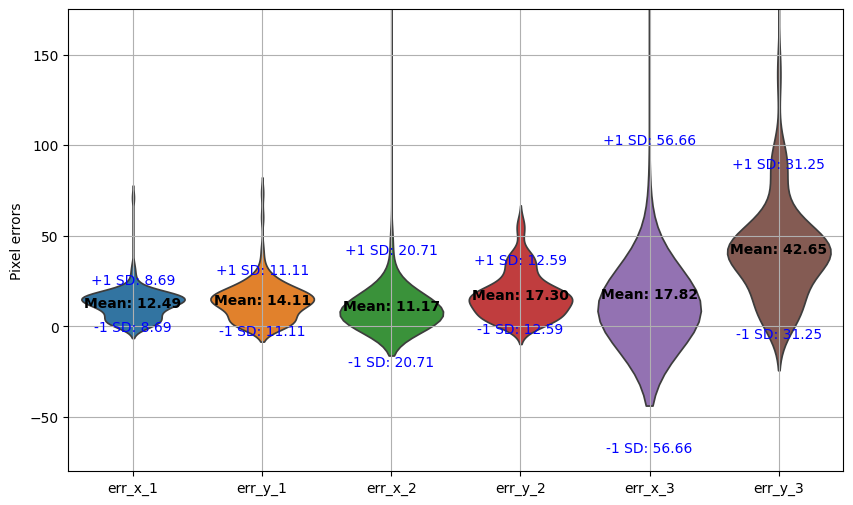

In [241]:
df_min = err_df
# Configurar el gráfico de violín
plt.figure(figsize=(10, 6))
cols = ["err_x_1", "err_y_1", "err_x_2", "err_y_2", "err_x_3", "err_y_3"]
sns.violinplot(data=df_min[cols], inner=None)  # Crear el diagrama de violín sin la línea interior
# Calcular y etiquetar el valor medio y la desviación estándar para cada columna
for i, col in enumerate(cols):
    mean = df_min[col].mean()
    std = df_min[col].std()
    
    # Agregar la etiqueta del valor medio
    plt.text(i, mean, f'Mean: {mean:.2f}', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    # Agregar la etiqueta de la desviación estándar
    plt.text(i, mean + 1.5*std, f'+1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)
    plt.text(i, mean - 1.5*std, f'-1 SD: {std:.2f}', ha='center', va='center', color='blue', fontsize=10)

# Configurar etiquetas y título
plt.ylim(-80, 175)
#plt.title('Error de detección entre el centro de la elipse (test) y el punto spine2 (train)')
#plt.xlabel('Posición de los puntos x, y por ratones')
plt.grid(True)
plt.ylabel('Pixel errors')

# Mostrar el gráfico
plt.show()

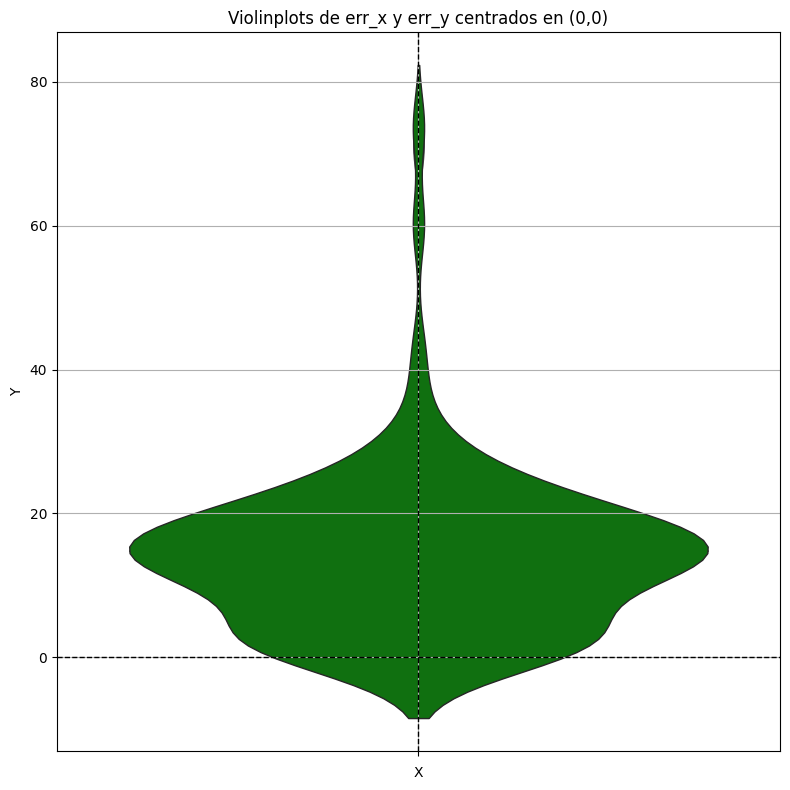

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

# --- 1. Cargar tus datos ---
# Supongamos que ya tienes df con columnas 'err_x' y 'err_y'

# --- 2. Preparar los datos en formato largo para seaborn ---
df_long = df_min.melt(df_min, value_vars=['err_x_1', 'err_y_1'], var_name='error_type', value_name='error_value')

# --- 3. Cargar imagen de fondo ---
# Reemplaza con tu ruta real
#image_path = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\github\photoneu\mice_key_points.jpg'
#img = mpimg.imread(image_path)

# --- 4. Crear figura y plot ---
fig, ax = plt.subplots(figsize=(8, 8))

# Mostrar imagen de fondo
#ax.imshow(img, extent=[-100, 100, -100, 100], aspect='auto')  # Ajusta los límites a tu escala

# Plotear los violines girados y centrados
# Para rotar y posicionar manualmente, usamos un truco: violinplot + transformación manual
for i, error_type in enumerate(['err_x_1', 'err_y_1']):
    values = df_min[error_type].dropna().values
    sns.violinplot(
        y=values,
        orient='v',
        inner=None,
        linewidth=1,
        ax=ax,
        color='blue' if error_type == 'err_x_1' else 'green'
    )
    # Mover el violín al eje x = 0 (para err_x) o y = 0 (para err_y)
    # Se manipula el artista gráfico directamente si se desea refinar

# Ajustes visuales
#ax.set_xlim(-100, 100)
#ax.set_ylim(-100, 100)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Violinplots de err_x y err_y centrados en (0,0)')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.grid(True)
plt.tight_layout()
plt.show()


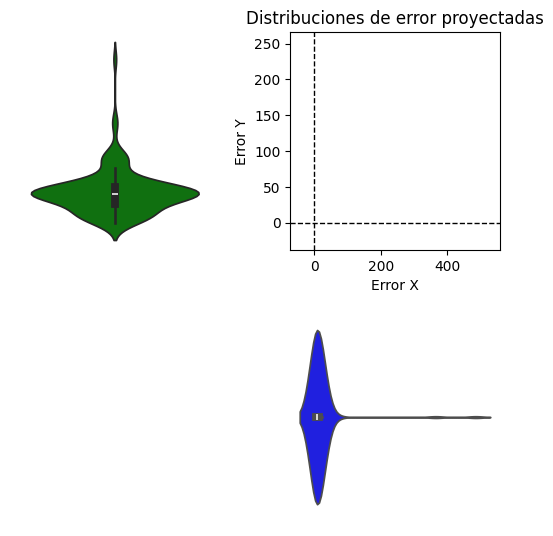

In [246]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
x = "err_x_3"
y = "err_y_3"
# Supongamos que df ya contiene 'err_x' y 'err_y'
# Asegúrate de que no tenga NaNs
df_min[x] = pd.to_numeric(df_min[x], errors='coerce').fillna(0.0)
df_min[y] = pd.to_numeric(df_min[y], errors='coerce').fillna(0.0)

# --- Configura la figura y ejes ---
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)

# Ejes principales (centro)
ax_main = fig.add_subplot(gs[1, 1])

# Violinplot err_x (abajo)
ax_x = fig.add_subplot(gs[2, 1], sharex=ax_main)

# Violinplot err_y (izquierda)
ax_y = fig.add_subplot(gs[1, 0], sharey=ax_main)

# --- Mostrar imagen de fondo en ax_main ---
# Ajusta el path a tu imagen
#img = mpimg.imread('tu_imagen.png')
#ax_main.imshow(img, extent=[-100, 100, -100, 100], aspect='auto')

# --- Ejes principales ---
ax_main.axhline(0, color='black', linestyle='--', linewidth=1)
ax_main.axvline(0, color='black', linestyle='--', linewidth=1)
#ax_main.set_xlim(-100, 100)
#ax_main.set_ylim(-100, 100)
ax_main.set_xlabel('Error X')
ax_main.set_ylabel('Error Y')
ax_main.set_title('Distribuciones de error proyectadas')

# --- Violinplot horizontal (err_x) ---
sns.violinplot(x=df_min[x], ax=ax_x, color='blue', orient='h')
ax_x.set_xlim(ax_main.get_xlim())
ax_x.axis('off')  # ocultamos ejes para estética

# --- Violinplot vertical (err_y) ---
sns.violinplot(y=df_min[y], ax=ax_y, color='green', orient='v')
ax_y.set_ylim(ax_main.get_ylim())
ax_y.axis('off')

plt.tight_layout()
plt.show()


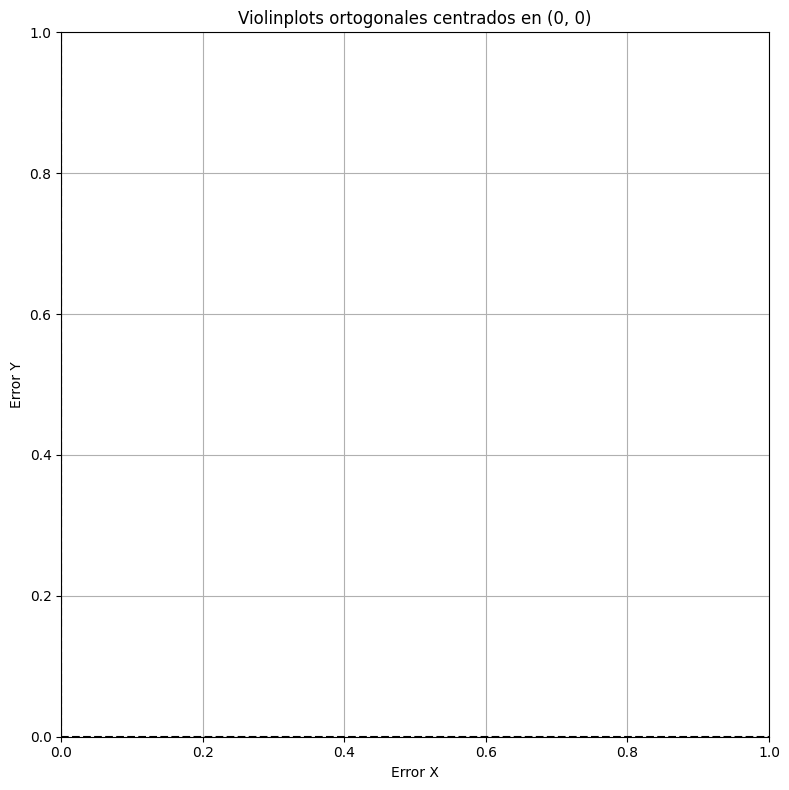

In [243]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.transforms import Affine2D
from matplotlib.patches import PathPatch

# --- Limpieza ---
df_min['err_x_1'] = pd.to_numeric(df_min['err_x_1'], errors='coerce').fillna(0.0)
df_min['err_y_1'] = pd.to_numeric(df_min['err_y_1'], errors='coerce').fillna(0.0)

# --- Crear figura principal ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- Imagen de fondo ---
#img = mpimg.imread('tu_imagen.png')
#ax.imshow(img, extent=[-100, 100, -100, 100], aspect='auto')

# --- Líneas guía ---
ax.axhline(0, color='black', linestyle='--')
ax.axvline(0, color='black', linestyle='--')

# --- Crear violín horizontal (err_x_1) en figura temporal ---
fig_x, ax_x = plt.subplots()
sns.violinplot(x=df_min['err_x_1'], ax=ax_x, color='blue', orient='h', inner='box', linewidth=1)
for coll in ax_x.collections:
    if isinstance(coll, PathPatch):
        new_patch = PathPatch(
            coll.get_path(),
            facecolor=coll.get_facecolor(),
            edgecolor=coll.get_edgecolor(),
            alpha=coll.get_alpha(),
            linewidth=coll.get_linewidth(),
            transform=Affine2D().translate(0, 0) + ax.transData
        )
        ax.add_patch(new_patch)
plt.close(fig_x)

# --- Crear violín vertical (err_y_1) en figura temporal ---
fig_y, ax_y = plt.subplots()
sns.violinplot(y=df_min['err_y_1'], ax=ax_y, color='green', orient='v', inner='box', linewidth=1)
for coll in ax_y.collections:
    if isinstance(coll, PathPatch):
        new_patch = PathPatch(
            coll.get_path(),
            facecolor=coll.get_facecolor(),
            edgecolor=coll.get_edgecolor(),
            alpha=coll.get_alpha(),
            linewidth=coll.get_linewidth(),
            transform=Affine2D().rotate_deg(90).translate(0, 0) + ax.transData
        )
        ax.add_patch(new_patch)
plt.close(fig_y)

# --- Ajustes finales ---
ax.set_xlabel('Error X')
ax.set_ylabel('Error Y')
ax.set_title('Violinplots ortogonales centrados en (0, 0)')
plt.grid(True)
plt.tight_layout()
plt.show()
